In [2]:
def read_iob2_file(path):
    """
    Read provided Universal NER iob2 file
    
    :param path: path to read from
    :returns: list with sequences of words and labels for each sentence
    """
    data = []
    current_words = []
    current_tags = []

    for line in open(path, encoding='utf-8'):
        line = line.strip()

        if line:
            if line[0] == '#':
                continue # skip comments
            tok = line.split('\t')

            current_words.append(tok[1])
            current_tags.append(tok[2])
        else:
            if current_words:  # skip empty lines
                data.append((current_words, current_tags))
            current_words = []
            current_tags = []

    # check for last one
    if current_tags != []:
        data.append((current_words, current_tags))
    return data

train_data = read_iob2_file('data/en_ewt-ud-train.iob2')
dev_data = read_iob2_file('data/en_ewt-ud-dev.iob2')

TRAIN_DATA_SIZE = len(train_data)
DEV_DATA_SIZE = len(dev_data)
MAX_LEN = max([len(x[0]) for x in train_data ])

print("Size of training data: ",TRAIN_DATA_SIZE)
print("Size of development data: ",DEV_DATA_SIZE)
print("Length of longest sentence: ",MAX_LEN)

Size of training data:  12543
Size of development data:  2001
Length of longest sentence:  159


In [7]:
import torch

class Vocab():
    def __init__(self, pad_unk='<PAD>'):
        """
        A convenience class that can help store a vocabulary
        and retrieve indices for inputs.
        """
        self.pad_unk = pad_unk
        self.word2idx = {self.pad_unk: 0}
        self.idx2word = [self.pad_unk]

    def getIdx(self, word, add=True):
        if word not in self.word2idx:
            if add:
                self.word2idx[word] = len(self.idx2word)
                self.idx2word.append(word)
            else:
                return self.word2idx[self.pad_unk]
        return self.word2idx[word]

    def getWord(self, idx):
        return self.idx2word[idx]

# Convert sentences into vectors of the same length of the longest sentence, filled with word/label indices
train_data_mat = torch.zeros(TRAIN_DATA_SIZE,MAX_LEN)
train_labels_mat = torch.zeros(TRAIN_DATA_SIZE,MAX_LEN)

# Store world/label indices
voc = Vocab()
labels = Vocab()

for i, x in enumerate(train_data):
    for j, word in enumerate(x[0]):
        train_data_mat[i,j] = voc.getIdx(word)
    for j, label in enumerate(x[1]):
        train_labels_mat[i,j] = labels.getIdx(label)

dev_data_mat = torch.zeros(DEV_DATA_SIZE,MAX_LEN)
dev_labels_mat = torch.zeros(DEV_DATA_SIZE,MAX_LEN)

for i, x in enumerate(dev_data):
    for j, word in enumerate(x[0]):
        dev_data_mat[i,j] = voc.getIdx(word, add=False)
    for j, label in enumerate(x[1]):
        dev_labels_mat[i,j] = labels.getIdx(label, add=False)

print(f"{len(labels.idx2word)} tags: {labels.idx2word}")
print(f"Vocab size: {len(voc.idx2word)}")

torch.Size([2001, 159])
torch.Size([12543, 159])
8 tags: ['<PAD>', 'O', 'B-LOC', 'I-LOC', 'B-PER', 'B-ORG', 'I-ORG', 'I-PER']
Vocab size: 19674


In [8]:
# Convert data into batches, will unfortunately throw away some part of the data
BATCH_SIZE = 16
BATCH_COUNT = int(len(train_data_mat)/BATCH_SIZE)

train_data_batches = train_data_mat[:BATCH_SIZE*BATCH_COUNT].view(BATCH_COUNT, BATCH_SIZE, train_data_mat.shape[1])
train_labels_batches = train_labels_mat[:BATCH_SIZE*BATCH_COUNT].view(BATCH_COUNT, BATCH_SIZE, train_labels_mat.shape[1])

print(train_data_batches.shape)
print(train_labels_batches.shape)

torch.Size([783, 16, 159])
torch.Size([783, 16, 159])


In [9]:
from torch import nn
import torch
torch.manual_seed(0)

# Hyperparameters
DIM_EMBEDDING = 100
RNN_HIDDEN = 50
BATCH_SIZE = 16
LEARNING_RATE = 0.01
EPOCHS = 10

# Model
class TaggerModel(torch.nn.Module):
    def __init__(self, nwords, ntags):
        super().__init__()
        self.l1 = nn.Embedding(nwords,DIM_EMBEDDING)
        self.l2 = nn.RNN(DIM_EMBEDDING, RNN_HIDDEN, batch_first=True)
        self.l3 = nn.Linear(RNN_HIDDEN, ntags)
        
    def forward(self, inputData):
        word_vectors = self.l1(inputData)
        rnn_out, _ = self.l2(word_vectors)
        pred_scores = self.l3(rnn_out)
        return pred_scores

# Init torch functions and models
model = TaggerModel(len(voc.idx2word), len(labels.idx2word))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_function = torch.nn.CrossEntropyLoss(ignore_index=0, reduction='sum')

# Run through epochs
for epoch in range(EPOCHS):
    print(">>> Epoch: " + str(epoch) + " <<<")

    # Set to training mode
    model.train()

    # Reset the gradient
    model.zero_grad()
    
    # Loop over each batch
    for i in range(BATCH_COUNT): 
        current_batch = train_data_batches[i].long()
        current_batch_labels = train_labels_batches[i].long()

        optimizer.zero_grad()
        tag_scores = model.forward(current_batch)

        tag_scores = tag_scores.view(BATCH_SIZE * MAX_LEN, -1)
        current_batch_labels = current_batch_labels.flatten()
        
        loss = loss_function(tag_scores, current_batch_labels)

        loss.backward()
        optimizer.step()

        if i%int(BATCH_COUNT/10) == 0:
            print(f"{round(i/BATCH_COUNT*100,2)}%")
        
# Set to evaluation mode
model.eval()

>>> Epoch: 0 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 1 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 2 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 3 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 4 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 5 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 6 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 7 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 8 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%
>>> Epoch: 9 <<<
0.0%
9.96%
19.92%
29.89%
39.85%
49.81%
59.77%
69.73%
79.69%
89.66%
99.62%


TaggerModel(
  (l1): Embedding(19674, 100)
  (l2): RNN(100, 50, batch_first=True)
  (l3): Linear(in_features=50, out_features=8, bias=True)
)

In [10]:
# >>> Testing model using dev set <<<
# Get dev predictions
dev_preds = model(dev_data_mat.long())

# Flatten matrices for evaluation
dev_preds = dev_preds.view(dev_preds.shape[0] * dev_preds.shape[1], -1)
temp_mat = dev_labels_mat.long().flatten()
# Mask for padding (in the perspective of the true labels), such that they aren't important in evaluation
non_zero_indices = torch.nonzero(temp_mat).flatten()

# Calculate loss
loss = loss_function(dev_preds[non_zero_indices], temp_mat[non_zero_indices])
loss

tensor(7399.6846, grad_fn=<NllLossBackward0>)

In [14]:
# Get the accuracy of the model
y_pred = torch.argmax(dev_preds[non_zero_indices], dim=1)
y_true = temp_mat[non_zero_indices]

accuracy = (y_pred == y_true).float().sum() / len(y_true)
accuracy = float(accuracy)

str(round(accuracy*100,2))+"%"

'93.18%'

In [23]:
from sklearn.metrics import confusion_matrix
import numpy as np

confusion_matrix(y_true, y_pred)

array([[0.96000507, 0.01547372, 0.00236756, 0.00152201, 0.01428994,
        0.00469285, 0.00164884],
       [0.17293233, 0.6716792 , 0.00250627, 0.02506266, 0.12030075,
        0.0075188 , 0.        ],
       [0.2972973 , 0.08783784, 0.37162162, 0.00675676, 0.0472973 ,
        0.16216216, 0.02702703],
       [0.12536443, 0.29446064, 0.        , 0.46355685, 0.10787172,
        0.00291545, 0.0058309 ],
       [0.33035714, 0.22321429, 0.00892857, 0.03571429, 0.37053571,
        0.03125   , 0.        ],
       [0.34946237, 0.12365591, 0.11827957, 0.        , 0.06451613,
        0.32258065, 0.02150538],
       [0.12755102, 0.19387755, 0.03061224, 0.05612245, 0.0255102 ,
        0.05102041, 0.51530612]])

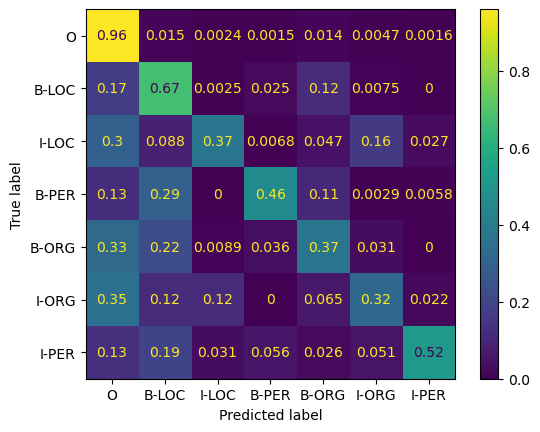

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)
norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=norm_cm, display_labels=labels.idx2word[1:])
disp.plot()

In [32]:
test_data = read_iob2_file('data/en_ewt-ud-test.iob2')

TEST_DATA_SIZE = len(test_data)

print("Size of test data: ",TEST_DATA_SIZE)

Size of test data:  2077


In [33]:
test_data_mat = torch.zeros(TRAIN_DATA_SIZE,MAX_LEN)
test_labels_mat = torch.zeros(TRAIN_DATA_SIZE,MAX_LEN)

for i, x in enumerate(test_data):
    for j, word in enumerate(x[0]):
        test_data_mat[i,j] = voc.getIdx(word, add=False)
    for j, label in enumerate(x[1]):
        test_labels_mat[i,j] = labels.getIdx(label, add=False)

In [34]:
# >>> Testing model using test set <<<
# Get test predictions
test_preds = model(test_data_mat.long())

# Flatten matrices for evaluation
test_preds = test_preds.view(test_preds.shape[0] * test_preds.shape[1], -1)
temp_mat = test_labels_mat.long().flatten()
# Mask for padding (in the perspective of the true labels), such that they aren't important in evaluation
non_zero_indices = torch.nonzero(temp_mat).flatten()

# Calculate loss
loss = loss_function(test_preds[non_zero_indices], temp_mat[non_zero_indices])
loss

tensor(7983.3413, grad_fn=<NllLossBackward0>)

In [36]:
# Get the accuracy of the model
y_pred = torch.argmax(test_preds[non_zero_indices], dim=1)
y_true = temp_mat[non_zero_indices]

accuracy = (y_pred == y_true).float().sum() / len(y_true)
accuracy = float(accuracy)

str(round(accuracy*100,2))+"%"

'92.68%'

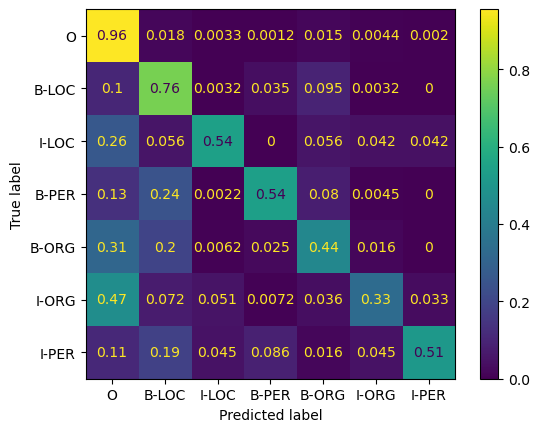

In [37]:
cm = confusion_matrix(y_true, y_pred)
norm_cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp = ConfusionMatrixDisplay(confusion_matrix=norm_cm, display_labels=labels.idx2word[1:])
disp.plot()

In [1]:
# Convert predictions of vocab indices into labels
y_pred_labels = [labels.idx2word[x] for x in y_pred]

NameError: name 'y_pred' is not defined

In [62]:
# Change all the true labels from the test data into predictions and output as file
data = []
it = 0

with open('data/en_ewt-ud-test.iob2','r') as f:
    for line in f.readlines():
        line = line.strip()

        if line:
            if line[0] == '#':
                data.append(line)
                continue
            tok = line.split('\t')

            tok[2] = y_pred_labels[it]
            it += 1
            
            tok = '\t'.join(tok)
            data.append(tok)
        else:
            data.append(line)

with open('shawarma_predictions.iob2', 'w') as f:
    for line in data:
        f.write(line+'\n')